## Import Library

In [2]:
!pip install vaderSentiment

In [3]:
#  STANDARD LIBRARIES
import re
import string
import pickle
import numpy as np
import pandas as pd

#  VISUALIZATION
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

#  NLP (Natural Language Processing)
import nltk
from nltk.corpus import stopwords, wordnet
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

#  MACHINE LEARNING 
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.preprocessing import LabelEncoder, LabelBinarizer
from sklearn.feature_extraction.text import TfidfVectorizer

#  DEEP LEARNING
import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Dropout, Embedding, LSTM
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

#SMOTE
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

In [4]:
# Unduh resource NLTK
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('wordnet')
nltk.download('vader_lexicon')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\rizki\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\rizki\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\rizki\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\rizki\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\rizki\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\rizki\AppData\Roaming\nltk

True

#Data Processing

##Load Data dan Cek Kardinalitas Data

In [5]:
df = pd.read_csv('reviews_com.kurogame.wutheringwaves.global_EN_20251003_022130.csv')

df.head(5)


,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,e3c321e4-89d1-49ef-99cd-7b92cdc3489f,Raymond Sampaga,https://play-lh.googleusercontent.com/a-/ALV-U...,absolutely perfect. i just want to say that co...,5,0,2.6.1,2025-10-02 01:38:55,NaN,NaN,2.6.1
1,c7f7ab7e-0018-4990-98d6-fb9a944a1108,Hillary Perez,https://play-lh.googleusercontent.com/a-/ALV-U...,yoo... much about i got lucky on this characte...,5,0,2.6.1,2025-10-01 23:15:38,NaN,NaN,2.6.1
2,3344c8a3-7bf0-4426-b558-25e66c084077,Rayden,https://play-lh.googleusercontent.com/a-/ALV-U...,best game in my life,5,0,2.6.1,2025-10-01 23:15:32,NaN,NaN,2.6.1
3,3f0d1687-6ae6-4fcc-b9c9-ec89c04bc056,KQ Demon,https://play-lh.googleusercontent.com/a-/ALV-U...,"one of, if not the best gacha game there is.",5,0,2.6.1,2025-10-01 22:51:45,NaN,NaN,2.6.1
4,acf50659-5c0d-440c-b4e6-7e613e729ddc,Danilo Palmenco,https://play-lh.googleusercontent.com/a/ACg8oc...,I played to and it's peak been playing since 1.0,5,0,NaN,2025-10-01 22:30:24,NaN,NaN,NaN


In [6]:
df = df[['content']]

In [7]:
# Pengecekan kardinalitas untuk setiap kolom
print("Kardinalitas data (jumlah nilai unik per kolom):")
print(df.nunique())

Kardinalitas data (jumlah nilai unik per kolom):
content    14673
dtype: int64


In [8]:
# Cek jumlah nilai kosong di kolom 'text'
print("Jumlah nilai kosong di kolom 'content' sebelum pembersihan:", df.isnull().sum())

# Cek jumlah duplikat di kolom 'content'
print("Jumlah duplikat di kolom 'content' sebelum pembersihan:", df.duplicated().sum())

# Hapus nilai kosong dan duplikat
df = df.dropna().drop_duplicates()

# Pengecekan ulang setelah pembersihan
print("\nJumlah nilai kosong di kolom 'content' setelah pembersihan:", df.isnull().sum())
print("Jumlah duplikat di kolom 'content' setelah pembersihan:", df.duplicated().sum())

Jumlah nilai kosong di kolom 'content' sebelum pembersihan: content    0
dtype: int64
Jumlah duplikat di kolom 'content' sebelum pembersihan: 537

Jumlah nilai kosong di kolom 'content' setelah pembersihan: content    0
dtype: int64
Jumlah duplikat di kolom 'content' setelah pembersihan: 0


In [9]:
df.head()

,content
0,absolutely perfect. i just want to say that co...
1,yoo... much about i got lucky on this characte...
2,best game in my life
3,"one of, if not the best gacha game there is."
4,I played to and it's peak been playing since 1.0


#Text Processing

##Inisialisasi

In [10]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

In [11]:
# Inisialisasi analyzer
analyzer = SentimentIntensityAnalyzer()

##Mapping POS Tag ke WordNet

In [12]:
def get_wordnet_pos(tag):
    if tag.startswith('J'):
        return wordnet.ADJ
    elif tag.startswith('V'):
        return wordnet.VERB
    elif tag.startswith('N'):
        return wordnet.NOUN
    elif tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN

##Cleaning emoji dan simbol

In [13]:
def cleaningText(content):
    emoji_pattern = re.compile(
        "[" u"\U0001F600-\U0001F64F"
        u"\U0001F300-\U0001F5FF"
        u"\U0001F680-\U0001F6FF"
        u"\U0001F1E0-\U0001F1FF"
        u"\U00002500-\U00002BEF"
        u"\U00002702-\U000027B0"
        u"\U000024C2-\U0001F251"
        "]+", flags=re.UNICODE)

    content = re.sub(r'@[A-Za-z0-9]+', '', content)         # Menghapus mentions
    content = re.sub(r'#[A-Za-z0-9]+', '', content)         # Menghapus hashtag
    content = re.sub(r'RT[\s]', '', content)                # Menghapus RT
    content = re.sub(r"http\S+", '', content)               # Menghapus link
    content = re.sub(r'[0-9]+', '', content)                # Menghapus angka
    content = re.sub(r'[^\w\s]', '', content)               # Menghapus karakter selain huruf/angka
    content = content.replace('\n', ' ')                    # Ganti baris baru jadi spasi
    content = content.translate(str.maketrans('', '', string.punctuation))  # Hapus tanda baca
    content = re.sub(r"\s+", " ", content).strip()          # Hapus spasi berlebih dan whitespace
    return content

##Case folding

In [14]:
def casefoldingText(content):
    content = content.lower()
    return content

##Standarisasi slang

In [15]:
slang_dict = {
    "u": "you",
    "r": "are",
    "ur": "your",
    "btw": "by the way",
    "idk": "i do not know",
    "lol": "laughing out loud",
    "omg": "oh my god",
    "lmao": "laughing my ass off",
    "rofl": "rolling on the floor laughing",
    "brb": "be right back",
    "gtg": "got to go",
    "imo": "in my opinion",
    "imho": "in my humble opinion",
    "fyi": "for your information",
    "tbh": "to be honest",
    "smh": "shaking my head",
    "np": "no problem",
    "jk": "just kidding",
    "nvm": "never mind",
    "bff": "best friend forever",
    "dm": "direct message",
    "tldr": "too long did not read",
    "wth": "what the heck",
    "ikr": "i know right",
    "ya": "yeah",
    "thx": "thanks",
    "ty": "thank you",
    "plz": "please",
    "bc": "because",
    "cuz": "because",
    "tho": "though",
    "k": "okay",
    "ok": "okay",
    "hbu": "how about you",
    "wyd": "what are you doing",
    "wbu": "what about you",
    "rn": "right now",
    "bday": "birthday",
    "gr8": "great",
    "luv": "love",
    "xoxo": "hugs and kisses",
    "yall": "you all",
    "sick": "awesome",
    "dope": "cool",
    "lit": "amazing",
    "fam": "friends",
    "salty": "upset",
    "shade": "disrespect",
    "tea": "gossip",
    "yolo": "you only live once",
    "fomo": "fear of missing out",
    "vibes": "feelings",
    "ive" : "i have"
}

In [16]:
def standard_slangwords(content):
    tokens = word_tokenize(content)
    return " ".join([slang_dict.get(t.lower(), t) for t in tokens])

##Tokenisasi

In [17]:
def tokenizingText(content):
    return word_tokenize(content)

##Stopword

In [18]:
important_stopwords = {
    # Negasi
    "not", "no", "nor", "never", "none", "nobody", "nothing", "neither",
    "n't", "don't", "didn't", "doesn't", "won't", "wouldn't", "can't",
    "cannot", "couldn't", "shouldn't", "mustn't", "isn't", "aren't",
    "wasn't", "weren't", "haven't", "hasn't", "hadn't", "without",
    "barely", "hardly", "scarcely",
    # Intensifier
    "very", "extremely", "really", "so", "too", "quite",
    # Penghubung penting
    "but", "although", "however", "yet"
}


custom_stop_words = stop_words - important_stopwords

In [19]:
def filteringText(tokens):
    # Hapus stopword dari token
    return [word for word in tokens if word.lower() not in custom_stop_words]


##Lemmatization

In [20]:
def lemmatizationText(tokens):
    pos_tags = pos_tag(tokens)
    return [lemmatizer.lemmatize(w, get_wordnet_pos(t)) for w, t in pos_tags]


##PipeLine Keseluruhan

In [21]:
# Terapkan pipeline lemmatization
clean_df = df.copy()
clean_df['text_clean'] = clean_df['content'].apply(cleaningText)
clean_df['text_casefoldingText'] = clean_df['text_clean'].apply(casefoldingText)
clean_df['text_slangwords'] = clean_df['text_casefoldingText'].apply(standard_slangwords)
clean_df['text_tokenizingText'] = clean_df['text_slangwords'].apply(tokenizingText)
clean_df['text_stopword'] = clean_df['text_tokenizingText'].apply(filteringText)
clean_df['lemmatized'] = clean_df['text_stopword'].apply(lemmatizationText)

clean_df.head()


,content,text_clean,text_casefoldingText,text_slangwords,text_tokenizingText,text_stopword,lemmatized
0,absolutely perfect. i just want to say that co...,absolutely perfect i just want to say that cou...,absolutely perfect i just want to say that cou...,absolutely perfect i just want to say that cou...,"[absolutely, perfect, i, just, want, to, say, ...","[absolutely, perfect, want, say, could, please...","[absolutely, perfect, want, say, could, please..."
1,yoo... much about i got lucky on this characte...,yoo much about i got lucky on this character o...,yoo much about i got lucky on this character o...,yoo much about i got lucky on this character o...,"[yoo, much, about, i, got, lucky, on, this, ch...","[yoo, much, got, lucky, character, maybe, im, ...","[yoo, much, get, lucky, character, maybe, im, ..."
2,best game in my life,best game in my life,best game in my life,best game in my life,"[best, game, in, my, life]","[best, game, life]","[best, game, life]"
3,"one of, if not the best gacha game there is.",one of if not the best gacha game there is,one of if not the best gacha game there is,one of if not the best gacha game there is,"[one, of, if, not, the, best, gacha, game, the...","[one, not, best, gacha, game]","[one, not, best, gacha, game]"
4,I played to and it's peak been playing since 1.0,I played to and its peak been playing since,i played to and its peak been playing since,i played to and its peak been playing since,"[i, played, to, and, its, peak, been, playing,...","[played, peak, playing, since]","[play, peak, playing, since]"


##Gabungkan Hasil Akhir

In [22]:
clean_df["text_akhir"] = clean_df["lemmatized"].apply(lambda x: " ".join(x))
clean_df['text_akhir'] = clean_df['text_akhir'].astype('str')
clean_df['text_akhir'] = clean_df['text_akhir'].astype(pd.StringDtype())

In [23]:
# Tampilkan contoh hasil
clean_df[['content', 'text_akhir']].head(10)

,content,text_akhir
0,absolutely perfect. i just want to say that co...,absolutely perfect want say could please add a...
1,yoo... much about i got lucky on this characte...,yoo much get lucky character maybe im curse go...
2,best game in my life,best game life
3,"one of, if not the best gacha game there is.",one not best gacha game
4,I played to and it's peak been playing since 1.0,play peak playing since
5,"the gameplay is good, but when I try to open t...",gameplay good but try open app later always co...
6,i really love this game. And it runs very smoo...,really love game run very smoothly great graph...
7,"Great game, liked it.",great game like
8,The best game I ever played in mobile games,best game ever play mobile game
9,GACHA 50/50 LOSE THREE RANDOM BAD,gacha lose three random bad


## Labelling

In [24]:
def vader_sentiment(text):
    scores = analyzer.polarity_scores(text)
    if scores['compound'] >= 0.05:
        return 'positive'  # Label 1
    elif scores['compound'] <= -0.05:
        return 'negative'  # Label 0
    else:
        return 'neutral'   # Label 2

In [25]:
# Terapkan fungsi pada kolom komentar
clean_df['sentiment_vader'] = clean_df['text_akhir'].apply(vader_sentiment)


# Tampilkan contoh hasil
clean_df[['content', 'text_akhir', 'sentiment_vader']].head()


,content,text_akhir,sentiment_vader
0,absolutely perfect. i just want to say that co...,absolutely perfect want say could please add a...,positive
1,yoo... much about i got lucky on this characte...,yoo much get lucky character maybe im curse go...,positive
2,best game in my life,best game life,positive
3,"one of, if not the best gacha game there is.",one not best gacha game,negative
4,I played to and it's peak been playing since 1.0,play peak playing since,positive


##Visualisasi Sentimen

In [26]:
positive_text = " ".join(clean_df[clean_df['sentiment_vader'] == 'positive']['text_akhir'])
neutral_text  = " ".join(clean_df[clean_df['sentiment_vader'] == 'neutral']['text_akhir'])
negative_text = " ".join(clean_df[clean_df['sentiment_vader'] == 'negative']['text_akhir'])

### Wordcloud

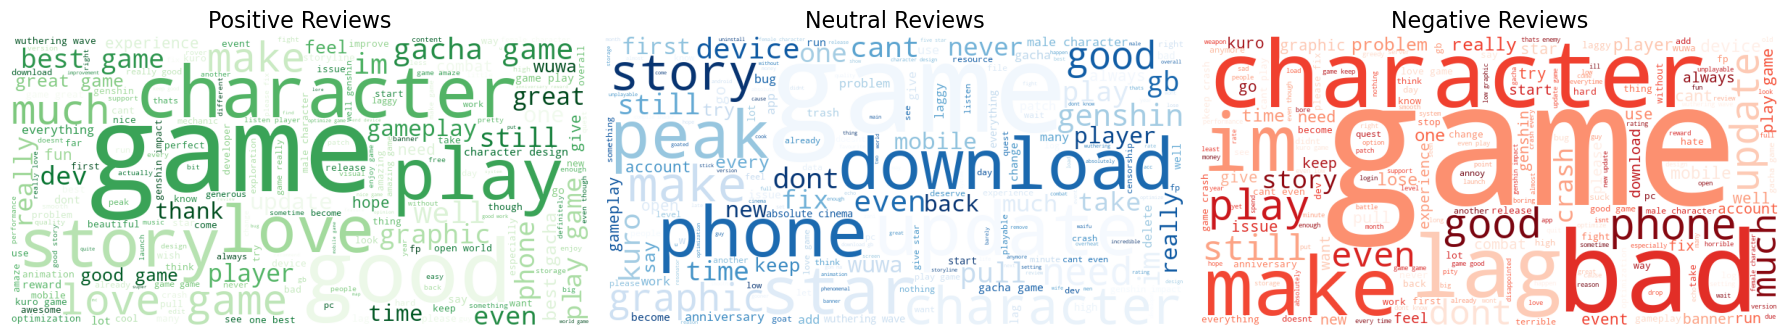

In [27]:
plt.figure(figsize=(18, 6))

# Positive
plt.subplot(1, 3, 1)
plt.imshow(WordCloud(width=800, height=400, background_color='white', colormap='Greens').generate(positive_text))
plt.title("Positive Reviews", fontsize=16)
plt.axis("off")

# Neutral
plt.subplot(1, 3, 2)
plt.imshow(WordCloud(width=800, height=400, background_color='white', colormap='Blues').generate(neutral_text))
plt.title("Neutral Reviews", fontsize=16)
plt.axis("off")

# Negative
plt.subplot(1, 3, 3)
plt.imshow(WordCloud(width=800, height=400, background_color='white', colormap='Reds').generate(negative_text))
plt.title("Negative Reviews", fontsize=16)
plt.axis("off")

plt.tight_layout()
plt.show()

###Bar Chart

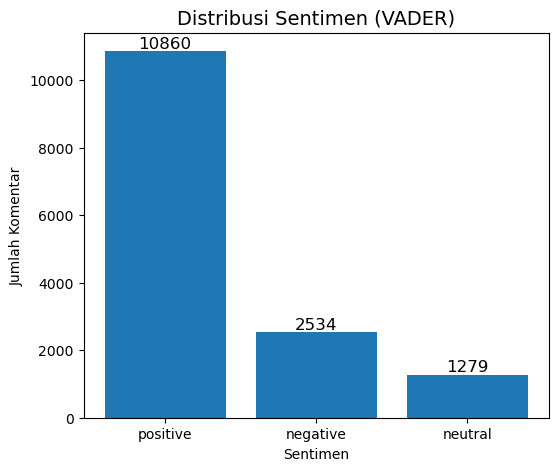

In [28]:
sentiment_counts = clean_df['sentiment_vader'].value_counts()

plt.figure(figsize=(6, 5))
bars = plt.bar(sentiment_counts.index, sentiment_counts.values)
plt.title("Distribusi Sentimen (VADER)", fontsize=14)
plt.xlabel("Sentimen")
plt.ylabel("Jumlah Komentar")

# Tambahkan label di atas bar
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             f"{int(bar.get_height())}", ha='center', va='bottom', fontsize=12)

plt.show()

## TF IDF

In [29]:

label_encoder = LabelEncoder()
clean_df['label'] = label_encoder.fit_transform(clean_df['sentiment_vader'])
clean_df['text_final'] = clean_df['lemmatized'].apply(lambda x: " ".join(x))

tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    stop_words='english'
)

X = tfidf.fit_transform(clean_df['text_final'])
y = clean_df['label']

print("Hasil TF-IDF:")
print(pd.DataFrame(X.toarray(), columns=tfidf.get_feature_names_out()).head())
print("Bentuk matriks TF-IDF:", X.shape)

Hasil TF-IDF:
   aaa  aaa game  aaa title  aalto  abandon  abby  ability  able  able clear  \
0  0.0       0.0        0.0    0.0      0.0   0.0      0.0   0.0         0.0   
1  0.0       0.0        0.0    0.0      0.0   0.0      0.0   0.0         0.0   
2  0.0       0.0        0.0    0.0      0.0   0.0      0.0   0.0         0.0   
3  0.0       0.0        0.0    0.0      0.0   0.0      0.0   0.0         0.0   
4  0.0       0.0        0.0    0.0      0.0   0.0      0.0   0.0         0.0   

   able enjoy  ...  zanis  zenless  zenless zone  zero  zhezhi  zone  \
0         0.0  ...    0.0      0.0           0.0   0.0     0.0   0.0   
1         0.0  ...    0.0      0.0           0.0   0.0     0.0   0.0   
2         0.0  ...    0.0      0.0           0.0   0.0     0.0   0.0   
3         0.0  ...    0.0      0.0           0.0   0.0     0.0   0.0   
4         0.0  ...    0.0      0.0           0.0   0.0     0.0   0.0   

   zone zero  zoom  zzz  zzz genshin  
0        0.0   0.0  0.0          

## SMOTE untuk Imbalanced Data

In [30]:
print("Sebelum SMOTE:", y.value_counts().to_dict())

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print("Setelah SMOTE:", dict(zip(*np.unique(y_resampled, return_counts=True))))



Sebelum SMOTE: {2: 10860, 0: 2534, 1: 1279}
Setelah SMOTE: {0: 10860, 1: 10860, 2: 10860}


## Split Data

In [31]:
X_train_70, X_test_30, y_train_70, y_test_30 = train_test_split(
    X_resampled, y_resampled, test_size=0.3, random_state=42, stratify=y_resampled
)

X_train_80, X_test_20, y_train_80, y_test_20 = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled
)

print("Bentuk data setelah split:")
print("70/30:", X_train_70.shape, X_test_30.shape)
print("80/20:", X_train_80.shape, X_test_20.shape)


Bentuk data setelah split:
70/30: (22806, 10000) (9774, 10000)
80/20: (26064, 10000) (6516, 10000)


##Modelling

In [32]:
models_params = {
    "LogisticRegression": {
        "model": LogisticRegression(max_iter=1000),
        "params": {
            "C": [0.5, 1, 5],
            "solver": ["liblinear", "lbfgs"]
        }
    },
    "SVM": {
        "model": SVC(),
        "params": {
            "C": [1, 5, 10],
            "kernel": ["linear", "rbf"],
            "gamma": ["scale", "auto"]
        }
    },
    "RandomForest": {
        "model": RandomForestClassifier(),
        "params": {
            "n_estimators": [200, 300],
            "max_depth": [20, 30, None],
            "min_samples_split": [2, 5]
        }
    },
    "KNN": {
        "model": KNeighborsClassifier(),
        "params": {
            "n_neighbors": [3, 5, 7],
            "weights": ["uniform", "distance"]
        }
    },
    "MultinomialNB": {
        "model": MultinomialNB(),
        "params": {
            "alpha": [0.1, 0.5, 1.0]
        }
    }
}

In [33]:
def train_evaluate(X_train, X_test, y_train, y_test, split_name):
    results = []
    best_models = {}

    for name, mp in models_params.items():
        print(f"\nMenjalankan {name} pada split {split_name}...")

        # RandomizedSearchCV untuk efisiensi
        search = RandomizedSearchCV(
            estimator=mp["model"],
            param_distributions=mp["params"],
            n_iter=5,             # jumlah kombinasi acak
            scoring='accuracy',
            cv=3,
            random_state=42,
            n_jobs=2              # batasi core agar stabil di Windows
        )

        search.fit(X_train, y_train)
        y_pred = search.best_estimator_.predict(X_test)
        acc = accuracy_score(y_test, y_pred)

        # Tampilkan hasil semua model
        print(f"{name} selesai. Accuracy: {acc:.4f}")
        print(classification_report(y_test, y_pred))

        # Simpan hasil hanya jika accuracy >= 0.89
        if acc >= 0.89:
            results.append({
                "Model": name,
                "Split": split_name,
                "Accuracy": acc,
                "Best Params": search.best_params_,
                "Best Estimator": search.best_estimator_
            })
            best_models[name] = {
                "model": search.best_estimator_,
                "accuracy": acc
            }

    return pd.DataFrame(results), best_models


In [34]:
results_7030, best_models_7030 = train_evaluate(X_train_70, X_test_30, y_train_70, y_test_30, "70/30")


Menjalankan LogisticRegression pada split 70/30...
LogisticRegression selesai. Accuracy: 0.8999
              precision    recall  f1-score   support

           0       0.89      0.87      0.88      3258
           1       0.87      0.97      0.92      3258
           2       0.95      0.85      0.90      3258

    accuracy                           0.90      9774
   macro avg       0.90      0.90      0.90      9774
weighted avg       0.90      0.90      0.90      9774


Menjalankan SVM pada split 70/30...
SVM selesai. Accuracy: 0.9323
              precision    recall  f1-score   support

           0       0.96      0.86      0.90      3258
           1       0.90      0.99      0.94      3258
           2       0.95      0.95      0.95      3258

    accuracy                           0.93      9774
   macro avg       0.93      0.93      0.93      9774
weighted avg       0.93      0.93      0.93      9774


Menjalankan RandomForest pada split 70/30...
RandomForest selesai. Accura

c:\Users\rizki\anaconda3\Lib\site-packages\sklearn\model_selection\_search.py:320: UserWarning: The total space of parameters 3 is smaller than n_iter=5. Running 3 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


MultinomialNB selesai. Accuracy: 0.8404
              precision    recall  f1-score   support

           0       0.77      0.88      0.82      3258
           1       0.91      0.85      0.88      3258
           2       0.86      0.79      0.82      3258

    accuracy                           0.84      9774
   macro avg       0.85      0.84      0.84      9774
weighted avg       0.85      0.84      0.84      9774



In [35]:
results_8020, best_models_8020 = train_evaluate(X_train_80, X_test_20, y_train_80, y_test_20, "80/20")


Menjalankan LogisticRegression pada split 80/20...
LogisticRegression selesai. Accuracy: 0.8998
              precision    recall  f1-score   support

           0       0.89      0.88      0.88      2172
           1       0.87      0.98      0.92      2172
           2       0.95      0.85      0.90      2172

    accuracy                           0.90      6516
   macro avg       0.90      0.90      0.90      6516
weighted avg       0.90      0.90      0.90      6516


Menjalankan SVM pada split 80/20...
SVM selesai. Accuracy: 0.9395
              precision    recall  f1-score   support

           0       0.96      0.87      0.92      2172
           1       0.90      0.99      0.95      2172
           2       0.96      0.95      0.96      2172

    accuracy                           0.94      6516
   macro avg       0.94      0.94      0.94      6516
weighted avg       0.94      0.94      0.94      6516


Menjalankan RandomForest pada split 80/20...
RandomForest selesai. Accura

c:\Users\rizki\anaconda3\Lib\site-packages\sklearn\model_selection\_search.py:320: UserWarning: The total space of parameters 3 is smaller than n_iter=5. Running 3 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


MultinomialNB selesai. Accuracy: 0.8422
              precision    recall  f1-score   support

           0       0.77      0.88      0.82      2172
           1       0.91      0.85      0.88      2172
           2       0.87      0.79      0.83      2172

    accuracy                           0.84      6516
   macro avg       0.85      0.84      0.84      6516
weighted avg       0.85      0.84      0.84      6516



In [36]:
final_results = pd.concat([results_7030, results_8020], ignore_index=True)
final_results.sort_values(by="Accuracy", ascending=False, inplace=True)

# Gabungkan semua best model
best_models = {**best_models_7030, **best_models_8020}

In [37]:
lb = LabelBinarizer()
y_train_70_bin = lb.fit_transform(y_train_70)
y_test_30_bin = lb.transform(y_test_30)

input_dim = X_train_70.shape[1]

mlp_model = Sequential([
    Dense(512, input_dim=input_dim, activation='relu'),
    Dropout(0.5),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(y_train_70_bin.shape[1], activation='softmax')
])

mlp_model.compile(optimizer=Adam(learning_rate=0.001),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

history_mlp = mlp_model.fit(
    X_train_70.toarray(), y_train_70_bin,
    validation_data=(X_test_30.toarray(), y_test_30_bin),
    epochs=20,
    batch_size=64,
    verbose=1
)


mlp_acc = mlp_model.evaluate(X_test_30.toarray(), y_test_30_bin, verbose=0)[1]
print("Akurasi MLP:", mlp_acc)

c:\Users\rizki\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
357/357 ━━━━━━━━━━━━━━━━━━━━ 21s 53ms/step - accuracy: 0.6617 - loss: 0.7196 - val_accuracy: 0.9119 - val_loss: 0.2623
Epoch 2/20
357/357 ━━━━━━━━━━━━━━━━━━━━ 18s 49ms/step - accuracy: 0.9463 - loss: 0.1649 - val_accuracy: 0.9378 - val_loss: 0.2032
Epoch 3/20
357/357 ━━━━━━━━━━━━━━━━━━━━ 18s 50ms/step - accuracy: 0.9742 - loss: 0.0804 - val_accuracy: 0.9381 - val_loss: 0.2080
Epoch 4/20
357/357 ━━━━━━━━━━━━━━━━━━━━ 18s 50ms/step - accuracy: 0.9808 - loss: 0.0601 - val_accuracy: 0.9435 - val_loss: 0.2024
Epoch 5/20
357/357 ━━━━━━━━━━━━━━━━━━━━ 20s 57ms/step - accuracy: 0.9851 - loss: 0.0470 - val_accuracy: 0.9334 - val_loss: 0.2649
Epoch 6/20
357/357 ━━━━━━━━━━━━━━━━━━━━ 17s 47ms/step - accuracy: 0.9862 - loss: 0.0441 - val_accuracy: 0.9452 - val_loss: 0.2257
Epoch 7/20
357/357 ━━━━━━━━━━━━━━━━━━━━ 16s 46ms/step - accuracy: 0.9893 - loss: 0.0365 - val_accuracy: 0.9393 - val_loss: 0.2609
Epoch 8/20
357/357 ━━━━━━━━━━━━━━━━━━━━ 18s 49ms/step - accuracy: 0.9882 - loss: 0.0360 - 

In [38]:
max_words = 10000
max_len = 100

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(clean_df['text_final'])

X_seq = tokenizer.texts_to_sequences(clean_df['text_final'])
X_pad = pad_sequences(X_seq, maxlen=max_len, padding='post', truncating='post')

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(clean_df['sentiment_vader'])

y_bin = lb.fit_transform(y)

X_train_seq, X_test_seq, y_train_seq, y_test_seq = train_test_split(
    X_pad, y_bin, test_size=0.3, random_state=42, stratify=y
)

lstm_model = Sequential([
    Embedding(input_dim=max_words, output_dim=128, input_length=max_len),
    LSTM(128, dropout=0.3, recurrent_dropout=0.3),
    Dense(64, activation='relu'),
    Dense(y_train_seq.shape[1], activation='softmax')
])

lstm_model.compile(optimizer=Adam(0.001), loss='categorical_crossentropy', metrics=['accuracy'])

history_lstm = lstm_model.fit(
    X_train_seq, y_train_seq,
    validation_data=(X_test_seq, y_test_seq),
    epochs=10,
    batch_size=64,
    verbose=1
)

lstm_acc = lstm_model.evaluate(X_test_seq, y_test_seq, verbose=0)[1]
print("Akurasi LSTM:", lstm_acc)

Epoch 1/10


c:\Users\rizki\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


161/161 ━━━━━━━━━━━━━━━━━━━━ 25s 133ms/step - accuracy: 0.7214 - loss: 0.7885 - val_accuracy: 0.7401 - val_loss: 0.7398
Epoch 2/10
161/161 ━━━━━━━━━━━━━━━━━━━━ 19s 117ms/step - accuracy: 0.7399 - loss: 0.7411 - val_accuracy: 0.7401 - val_loss: 0.7389
Epoch 3/10
161/161 ━━━━━━━━━━━━━━━━━━━━ 18s 110ms/step - accuracy: 0.7439 - loss: 0.7362 - val_accuracy: 0.7401 - val_loss: 0.7401
Epoch 4/10
161/161 ━━━━━━━━━━━━━━━━━━━━ 26s 163ms/step - accuracy: 0.7344 - loss: 0.7531 - val_accuracy: 0.7401 - val_loss: 0.7388
Epoch 5/10
161/161 ━━━━━━━━━━━━━━━━━━━━ 18s 109ms/step - accuracy: 0.7358 - loss: 0.7434 - val_accuracy: 0.7401 - val_loss: 0.7397
Epoch 6/10
161/161 ━━━━━━━━━━━━━━━━━━━━ 18s 109ms/step - accuracy: 0.7313 - loss: 0.7536 - val_accuracy: 0.7401 - val_loss: 0.7389
Epoch 7/10
161/161 ━━━━━━━━━━━━━━━━━━━━ 18s 111ms/step - accuracy: 0.7396 - loss: 0.7446 - val_accuracy: 0.7401 - val_loss: 0.7393
Epoch 8/10
161/161 ━━━━━━━━━━━━━━━━━━━━ 18s 112ms/step - accuracy: 0.7417 - loss: 0.7373 - val

In [39]:
# SIMPAN MODEL TERBAIK

all_models = []

# Tambahkan semua model ML terbaik
for name, info in best_models.items():
    all_models.append({
        "name": name,
        "type": "ml",
        "model": info["model"],
        "accuracy": info["accuracy"]
    })

# Tambahkan model DL
all_models.extend([
    {"name": "MLP", "type": "dl", "model": mlp_model, "accuracy": mlp_acc},
    {"name": "LSTM", "type": "dl", "model": lstm_model, "accuracy": lstm_acc}
])

# Pilih model terbaik
best_model_info = max(all_models, key=lambda x: x['accuracy'])
best_model = best_model_info['model']
best_name = best_model_info['name']
best_type = best_model_info['type']
best_acc = best_model_info['accuracy']

print(f"\nModel terbaik: {best_name} | Tipe: {best_type} | Akurasi: {best_acc:.4f}")


if best_type == "ml":
    # Model ML: simpan pickle + TF-IDF
    with open(f"{best_name}_best_model.pkl", "wb") as f:
        pickle.dump(best_model, f)
    with open("tfidf_vectorizer.pkl", "wb") as f:
        pickle.dump(tfidf, f)
    print(f"Model {best_name} (ML) dan TF-IDF berhasil disimpan.")

else:
    # Model DL: simpan .h5
    best_model.save(f"{best_name}_best_model.h5")
    # Simpan tokenizer hanya jika model berbasis sequence (LSTM)
    if best_name == "LSTM":
        with open("tokenizer.pkl", "wb") as f:
            pickle.dump(tokenizer, f)
        print(f"Model {best_name} (DL) dan tokenizer berhasil disimpan.")
    else:
        print(f"Model {best_name} (DL) berhasil disimpan (MLP TF-IDF).")

# Simpan label encoder
with open("label_encoder.pkl", "wb") as f:
    pickle.dump(label_encoder, f)
print("Label encoder berhasil disimpan.")



Model terbaik: SVM | Tipe: ml | Akurasi: 0.9395
Model SVM (ML) dan TF-IDF berhasil disimpan.
Label encoder berhasil disimpan.


## Inference

In [40]:
# INFERENCE INTERAKTIF (SAMPAI USER KETIK "exit")

# 1. Load model
print("Memuat model dan preprocessor...")

if best_type == "ml":
    with open(f"{best_name}_best_model.pkl", "rb") as f:
        model = pickle.load(f)
    with open("tfidf_vectorizer.pkl", "rb") as f:
        tfidf = pickle.load(f)
else:
    model = load_model(f"{best_name}_best_model.h5")
    if best_name == "LSTM":
        with open("tokenizer.pkl", "rb") as f:
            tokenizer = pickle.load(f)

with open("label_encoder.pkl", "rb") as f:
    label_encoder = pickle.load(f)

print("Model dan preprocessor berhasil dimuat.\n")


# 2. Loop input komentar sampai exit

print("💡 Ketik 'exit' untuk keluar dari inferensi.\n")

while True:
    text_input = input("Masukkan komentar: ").strip()
    
    if text_input.lower() == "exit":
        print(" Keluar dari inferensi.")
        break
    elif not text_input:
        print(" Tidak ada input teks. Silakan masukkan komentar.")
        continue

    
    # 3. Preprocessing & prediksi
    
    if best_type == "ml":
        X_input = tfidf.transform([text_input]).toarray()
        y_pred = model.predict(X_input)
    else:
        if best_name == "LSTM":
            seq = tokenizer.texts_to_sequences([text_input])
            X_input = pad_sequences(seq, maxlen=100, padding='post', truncating='post')
        else:
            # MLP berbasis TF-IDF
            X_input = tfidf.transform([text_input]).toarray()

        y_pred = model.predict(X_input)
        y_pred = np.argmax(y_pred, axis=1)

    
    # 4. Konversi label
    label_pred = label_encoder.inverse_transform(y_pred)

    # 5. Tampilkan hasil
    print("\n================ HASIL PREDIKSI ================")
    print(f" Komentar: {text_input}")
    print(f" Prediksi Sentimen: {label_pred[0]}")
    print("================================================\n")


Memuat model dan preprocessor...
Model dan preprocessor berhasil dimuat.

💡 Ketik 'exit' untuk keluar dari inferensi.


================ HASIL PREDIKSI ================
 Komentar: good game
 Prediksi Sentimen: positive


================ HASIL PREDIKSI ================
 Komentar: this is suck
 Prediksi Sentimen: negative


================ HASIL PREDIKSI ================
 Komentar: preaty good
 Prediksi Sentimen: positive


================ HASIL PREDIKSI ================
 Komentar: this is perfect game
 Prediksi Sentimen: positive

 Keluar dari inferensi.


In [2]:
!pip freeze > requirements.txt
